# 72-hour SHARP conformal uncertainty evaluation
**Notebook 03 · Bamidele Akinwumi · candidate-label research experiment**

## tl;dr
**The fixed 2015 conformal thresholds did not retain the requested class coverage in later data.** At the primary 90% target, GRU pooled sets covered 86.4% of all Cycle-25 outcomes but only 12.6% of flare outcomes. Class-conditional flare coverage was 73.5% in Cycle 25 and 43.5% in partial 2026. At the 95% sensitivity, those class-conditional figures rose to 91.8% and 71.9%, still below the target. The logistic reference showed similar failures.

Thresholds use 4,168 earlier windows, including 384 positive windows. Both declared levels and methods are preserved; none is selected from evaluation. Counts are forecast windows, labels remain provisional, and these retrospective results do not certify operational reliability. Full details, denominators and conditional resampling intervals follow below.

## Context & Methods

**Question:** do uncertainty sets retain coverage for rare M/X flare outcomes when transferred from earlier data into Cycle 25, and how much ambiguity does that coverage require?

The target is a science-class M/X flare **starting within the next 72 hours for the primary NOAA region**. Class 0 means no qualifying M/X start in this window, not an absence of all solar activity. Both the GRU ensemble and logistic reference use the earlier-selected raw probabilities from Notebook 02.

Compare **pooled split conformal** with **class-conditional (Mondrian) split conformal**, using the same score $s(x,y)=1-\hat p_y(x)$. At each declared miscoverage level $\alpha$, take the $\lceil(n+1)(1-\alpha)\rceil$-th smallest calibration score. If that rank exceeds the available count, use infinity. Include a candidate class when its score is less than or equal to its threshold; retain ties and empty sets. Class-conditional fitting uses a separate score sample for each true class. No label is needed when issuing a set.

**Fixed comparisons:** 90% target coverage is primary; 95% is a sensitivity. All methods and levels are retained. No method, level or threshold is chosen from evaluation performance.

### Key Assumptions

- Fit only the reserved January–June 2015 conformal block. The frozen split purges cases whose 72-hour outcome plus assumed 24-hour reporting delay crosses 1 July 2015.
- Evaluate the existing 2021–2025 retrospective block and partial 2026 supplementary block. Counts are overlapping forecast windows, not independent flare events.
- Standard coverage theory needs exchangeability; cross-cycle drift and dependence make that assumption questionable here. Nominal 90%/95% levels are targets to check, not operational guarantees.
- Coverage is the fraction of known outcomes included in their issued sets. Report it overall and separately by class. Set size is 0, 1 or 2; a singleton is not proof that a forecast is safe.
- Intervals use 1,000 region-component bootstrap resamples, with seven-day UTC block sensitivity for aggregate periods. They condition on fixed thresholds/models/labels, omit their estimation uncertainty, and are per-comparison rather than simultaneous intervals. Annual plots use region resampling only.
- Unknown outcomes never become negatives. Unsupported SHARP input rows remain unscored; rows before the conformal fitting cutoff receive no retrospectively backdated sets.
- This is binary classification. Conformalized quantile regression for a continuous target is not implemented, and these sets are not intervals for a latent flare probability.
- Policy-development labels remain unused for fitting or evaluation. No normal/degraded/abstention safety policy is validated here.

Method references: [Angelopoulos & Bates, §§1 and 4.2](https://arxiv.org/html/2107.07511v6) and [Barber et al., Conformal prediction beyond exchangeability](https://arxiv.org/abs/2202.13415). The date splits, alpha levels and resampling design are experimental choices.

## Data
### 1. Environment
Use the project training kernel and `requirements-notebook.txt`. For a fresh environment, optionally install the packages below. Set the paths to your local frozen artifacts. No cloud execution or remote data download is required.

In [1]:
INSTALL_DEPENDENCIES = False
if INSTALL_DEPENDENCIES:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy==2.3.5', 'pandas==2.2.3', 'matplotlib==3.10.7'])

from datetime import datetime, timezone
from decimal import Decimal, ROUND_CEILING
import hashlib
import json
from pathlib import Path
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Markdown

WORKSPACE = Path.cwd()
if WORKSPACE.name == 'notebooks':
    WORKSPACE = WORKSPACE.parent
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.dpi': 115, 'axes.titleweight': 'bold'})
METHOD_COLORS = {'pooled': '#245A81', 'class_conditional': '#B36B19'}
METHOD_NAMES = {'pooled': 'Pooled', 'class_conditional': 'Class-conditional'}
PERIOD_NAMES = {'retrospective_cycle25': '2021–2025', 'supplementary_2026': '2026 (partial)'}
print({'numpy': np.__version__, 'pandas': pd.__version__})

{'numpy': '2.3.5', 'pandas': '2.2.3'}


### 2. Pinned inputs and declared protocol

In [2]:
CONFIG = json.loads(r'''{
  "experiment": "sharp72_conformal_candidate_v1",
  "parent_dir": "outputs/sharp72_calibration_v1_20261002T083245963780Z",
  "calibration_summary_sha256": "bbdba037ac756ef4ea0b71299439f76fe1f0135595cb2ed0542afe2cbceb9811",
  "dataset_manifest_sha256": "7bb88614482cacd5fafb145d88345132a6cf97b25b8313dbefd90b08ac5b9d27",
  "horizon": 72,
  "scope": "primary",
  "calibration_start": "2015-01-01",
  "calibration_end": "2015-07-01",
  "reporting_delay_hours": 24,
  "models": [
    "gru",
    "logistic"
  ],
  "methods": [
    "pooled",
    "class_conditional"
  ],
  "score": "1 minus selected probability of the candidate class",
  "alphas": [
    0.1,
    0.05
  ],
  "primary_alpha": 0.1,
  "quantile": "ceil((n+1)*(1-alpha))-th order statistic; infinity if rank exceeds n; inclusive ties",
  "evaluation_roles": [
    "retrospective_cycle25",
    "supplementary_2026"
  ],
  "bootstrap_repetitions": 1000,
  "bootstrap_seed": 31415,
  "bootstrap_groups": [
    "region_component",
    "calendar_7day_UTC"
  ],
  "selection": "No method or alpha selected using evaluation; alpha 0.1 primary, 0.05 sensitivity"
}''')
PARENT_DIR = WORKSPACE / CONFIG['parent_dir']
DATASET_DIR = WORKSPACE / 'data/processed/training_snapshot_20261002/gray_box_aligned_v1'
OUTPUT_DIR = WORKSPACE / 'outputs' / ('sharp72_conformal_v1_' + datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ'))
print('Frozen probabilities:', PARENT_DIR)
print('New run:', OUTPUT_DIR)
display(pd.DataFrame([
    {'Use': 'Conformal fit', 'Start': '2015-01-01', 'End': '2015-07-01 exclusive'},
    {'Use': 'Policy development — reserved', 'Start': '2015-07-01', 'End': '2020-01-01 exclusive'},
    {'Use': 'Retrospective evaluation', 'Start': '2021-01-01', 'End': '2026-01-01 exclusive'},
    {'Use': 'Supplementary evaluation', 'Start': '2026-01-01', 'End': 'latest eligible case in frozen source'}]))

Frozen probabilities: /Users/mac/Documents/ChatGPT/Imaging_Project/gray-box-solar-flare-forecasting/outputs/sharp72_calibration_v1_20261002T083245963780Z
New run: /Users/mac/Documents/ChatGPT/Imaging_Project/gray-box-solar-flare-forecasting/outputs/sharp72_conformal_v1_20261002T085647154969Z


,Use,Start,End
0,Conformal fit,2015-01-01,2015-07-01 exclusive
1,Policy development — reserved,2015-07-01,2020-01-01 exclusive
2,Retrospective evaluation,2021-01-01,2026-01-01 exclusive
3,Supplementary evaluation,2026-01-01,latest eligible case in frozen source


### 3. Source integrity and identity checks
All parent artifacts are verified against pinned hashes before any fitting. The master table supplies outcome boundaries and confirms the target labels.

In [3]:
def sha256(path):
    with Path(path).open('rb') as stream:
        return hashlib.file_digest(stream, 'sha256').hexdigest()

def save_json(path, value):
    Path(path).write_text(json.dumps(value, indent=2, allow_nan=False) + '\n')

def validate_probabilities(p, y=None):
    p = np.asarray(p, dtype=float)
    if p.ndim != 1 or not np.isfinite(p).all() or ((p < 0) | (p > 1)).any():
        raise ValueError('Probabilities must be a finite vector in [0,1]')
    if y is not None and (np.shape(y) != p.shape or not np.isin(y, [0, 1]).all()):
        raise ValueError('Unknown outcomes cannot enter conformal fitting or metrics')
    return p

def load_sources(parent_dir, dataset, config):
    if sha256(parent_dir / 'summary.json') != config['calibration_summary_sha256']:
        raise ValueError('Frozen calibration summary changed')
    parent = json.loads((parent_dir / 'summary.json').read_text())
    for name, expected in parent['output_sha256'].items():
        if sha256(parent_dir / name) != expected:
            raise ValueError(f'Frozen calibration artifact changed: {name}')
    contract = json.loads((parent_dir / 'run_contract.json').read_text())
    if contract['config']['horizon'] != 72 or contract['config']['scope'] != 'primary':
        raise ValueError('Wrong parent target')
    if config['horizon'] != 72 or config['scope'] != 'primary':
        raise ValueError('This experiment is for 72h primary targets')
    if sha256(dataset / 'manifest.json') != config['dataset_manifest_sha256']:
        raise ValueError('Dataset manifest changed')
    manifest = json.loads((dataset / 'manifest.json').read_text())
    if sha256(dataset / 'master_cases.csv.gz') != manifest['outputs']['master_cases.csv.gz']['sha256']:
        raise ValueError('Master-case table changed')
    master = pd.read_csv(dataset / 'master_cases.csv.gz', low_memory=False)
    frame = pd.read_csv(parent_dir / 'calibrated_predictions.csv.gz')
    population = pd.read_csv(parent_dir / 'population_predictions.csv.gz')
    frame = frame.merge(master[['forecast_case_id', 'outcome_end_utc_72h', 'candidate_primary_label_72h']],
                        on='forecast_case_id', how='left', validate='one_to_one')
    if frame.outcome_end_utc_72h.isna().any() or not np.array_equal(frame.label, frame.candidate_primary_label_72h.fillna(-1)):
        raise ValueError('Missing cases or conflicting labels')
    if not np.array_equal(frame.label_known, frame.label.isin([0, 1])):
        raise ValueError('Conflicting known-outcome mask')
    if population.forecast_case_id.duplicated().any() or set(population.forecast_case_id) != set(master.forecast_case_id):
        raise ValueError('Full-population identities changed')
    for model in config['models']:
        method = parent['selected_methods'][model]
        if not np.array_equal(frame[f'{model}_selected'], frame[f'{model}_{method}']):
            raise ValueError('Selected probabilities changed')
        validate_probabilities(frame[f'{model}_selected'])
    return frame, population, parent

### 4. Fit exact order statistics and produce sets
Each method reads only the conformal-calibration role. JSON null plus `include_all=true` represents an infinite threshold when support is insufficient. Ties are included without randomization.

In [4]:
def finite_sample_threshold(scores, alpha):
    scores = validate_probabilities(scores)
    a = Decimal(str(alpha))
    if not 0 < a < 1:
        raise ValueError('alpha must be strictly between zero and one')
    n = len(scores)
    rank = int((Decimal(n + 1) * (1-a)).to_integral_value(rounding=ROUND_CEILING))
    # A missing class or rank n+1 means +infinity, represented by JSON null.
    threshold = float(np.partition(scores, rank-1)[rank-1]) if rank <= n else None
    return {'n': n, 'rank': rank, 'threshold': threshold,
            'include_all': threshold is None}

def fit_thresholds(p, y, method, alpha):
    p = validate_probabilities(p, y)
    y = np.asarray(y, dtype=int)
    scores = np.where(y == 1, 1-p, p)
    if method == 'pooled':
        q = finite_sample_threshold(scores, alpha)
        thresholds = {'0': q, '1': q.copy()}
    elif method == 'class_conditional':
        thresholds = {str(k): finite_sample_threshold(scores[y == k], alpha) for k in [0, 1]}
    else:
        raise ValueError('Unknown conformal method')
    return {'method': method, 'alpha': alpha, 'thresholds': thresholds}

def predict_sets(p, parameters):
    p = validate_probabilities(p)
    scores = np.column_stack([p, 1-p])
    q = [np.inf if parameters['thresholds'][str(k)]['include_all'] else parameters['thresholds'][str(k)]['threshold'] for k in [0, 1]]
    # Inclusive ties are conservative; no randomized tie-breaking or forced singleton.
    return scores <= np.asarray(q)

def conformal_mask(frame, config):
    issue = pd.to_datetime(frame.issue_utc, utc=True, format='ISO8601')
    end = pd.to_datetime(frame.outcome_end_utc_72h, utc=True, format='ISO8601')
    start, stop = (pd.Timestamp(config[k], tz='UTC') for k in ['calibration_start', 'calibration_end'])
    if start >= stop or config['reporting_delay_hours'] < 0:
        raise ValueError('Invalid calibration information boundary')
    role = frame.role.eq('conformal_calibration')
    valid_time = (issue >= start) & (issue < stop) & (end + pd.Timedelta(hours=config['reporting_delay_hours']) <= stop)
    if (role & ~valid_time).any():
        raise ValueError('Conformal role violates issue/outcome/reporting boundary')
    known = frame.label.isin([0, 1]) & frame.label_known
    return (role & known).to_numpy()

def freeze_thresholds(frame, config):
    mask = conformal_mask(frame, config)
    if not mask.any():
        raise ValueError('No eligible conformal calibration cases')
    models = {}
    for model in config['models']:
        if frame.loc[mask, f'{model}_selected'].isna().any():
            raise ValueError('Calibration probabilities missing')
        models[model] = {method: {str(alpha): fit_thresholds(frame.loc[mask, f'{model}_selected'].to_numpy(),
                            frame.loc[mask, 'label'].to_numpy(), method, alpha)
                            for alpha in config['alphas']} for method in config['methods']}
    selected = frame.loc[mask]
    return {'models': models, 'support': {'cases': len(selected), 'nonflare': int(selected.label.eq(0).sum()),
            'flare': int(selected.label.eq(1).sum()), 'region_components': int(selected.region_component_id.nunique()),
            'first_issue_utc': str(selected.issue_utc.min()), 'last_issue_utc': str(selected.issue_utc.max())},
            'fit_case_ids_sha256': hashlib.sha256('\n'.join(sorted(selected.forecast_case_id)).encode()).hexdigest()}

### 5. Define coverage, ambiguity and singleton errors
The singleton error is conditional on the subset receiving exactly one label. It is a descriptive diagnostic, not a controlled selective-risk guarantee. Flare cases assigned only class 0 are also reported explicitly.

In [5]:
def set_metrics(y, sets):
    y = np.asarray(y)
    sets = np.asarray(sets)
    if not len(y) or sets.shape != (len(y), 2) or sets.dtype != bool or not np.isin(y, [0, 1]).all():
        raise ValueError('Need nonempty known binary outcomes and boolean prediction sets')
    y = y.astype(int)
    size = sets.sum(axis=1)
    covered = sets[np.arange(len(y)), y]
    singleton = size == 1
    counts = {'empty': size == 0, 'nonflare_only': (size == 1) & sets[:, 0],
              'flare_only': (size == 1) & sets[:, 1], 'both': size == 2}
    result = {'cases': len(y), 'nonflare_cases': int((y == 0).sum()), 'flare_cases': int((y == 1).sum()),
              'covered': int(covered.sum()), 'coverage': float(covered.mean()), 'mean_set_size': float(size.mean()),
              'singleton_cases': int(singleton.sum()), 'singleton_fraction': float(singleton.mean()),
              'singleton_error': float((~covered[singleton]).mean()) if singleton.any() else None}
    for label, name in [(0, 'nonflare'), (1, 'flare')]:
        selected = y == label
        result[f'{name}_covered'] = int(covered[selected].sum())
        result[f'{name}_coverage'] = float(covered[selected].mean()) if selected.any() else None
    for name, selected in counts.items():
        result[f'{name}_count'] = int(selected.sum())
        result[f'{name}_fraction'] = float(selected.mean())
    result['flare_singleton_nonflare_count'] = int(((y == 1) & counts['nonflare_only']).sum())
    result['flare_singleton_nonflare_rate'] = result['flare_singleton_nonflare_count'] / result['flare_cases'] if result['flare_cases'] else None
    return result

### 6. Resample groups, preserving all windows within each group
Intervals are suppressed if a class has fewer than two supported groups or over 5% of resamples have no such class. They do not account for shared events across different groups or establish independence.

In [6]:
def coverage_bootstrap(y, sets, groups, repetitions=1000, seed=31415):
    y = np.asarray(y, dtype=int)
    set_metrics(y, sets)
    if pd.isna(groups).any():
        raise ValueError('Missing resampling group')
    covered = sets[np.arange(len(y)), y]
    raw = {'group': np.asarray(groups)}
    for name, selected in [('all', np.ones(len(y), dtype=bool)), ('nonflare', y == 0), ('flare', y == 1)]:
        raw[name + '_n'] = selected.astype(int)
        raw[name + '_covered'] = (covered & selected).astype(int)
    grouped = pd.DataFrame(raw).groupby('group', sort=True).sum()
    n = len(grouped)
    weights = np.random.default_rng(seed).multinomial(n, np.full(n, 1/n), size=repetitions)
    totals = weights @ grouped.to_numpy()
    sampled = dict(zip(grouped.columns, totals.T))
    rows = []
    for name in ['all', 'nonflare', 'flare']:
        denom = int(grouped[name + '_n'].sum())
        supported_groups = int(grouped[name + '_n'].gt(0).sum())
        valid = sampled[name + '_n'] > 0
        draws = sampled[name + '_covered'][valid] / sampled[name + '_n'][valid]
        estimable = supported_groups >= 2 and valid.sum() >= .95 * repetitions
        low, high = np.quantile(draws, [.025, .975]) if estimable else (None, None)
        rows.append({'population': name, 'cases': denom, 'groups': n, 'groups_with_class': supported_groups,
                     'coverage': float(grouped[name + '_covered'].sum()/denom) if denom else None,
                     'low': float(low) if low is not None else None, 'high': float(high) if high is not None else None,
                     'valid_repetitions': int(valid.sum()), 'interval_status': 'conditional_cluster_percentile' if estimable else 'insufficient_group_support'})
    return rows

### 7. Execute the frozen protocol
Save thresholds before evaluating later outcomes. Preserve every candidate case in the output. Set codes are 0=empty, 1={0}, 2={1}, 3={0,1}; a blank code means no set issued. Sets after the cutoff can be issued without knowing the outcome.

In [7]:
def run_conformal(parent_dir, dataset, config, output, source_code):
    if output.exists():
        raise ValueError('Choose a new output directory; never overwrite a frozen run')
    frame, population, parent = load_sources(parent_dir, dataset, config)
    output.parent.mkdir(parents=True, exist_ok=True)
    staging = Path(tempfile.mkdtemp(prefix=output.name + '.incomplete-', dir=output.parent))
    try:
        frozen = freeze_thresholds(frame, config)
        save_json(staging / 'thresholds.json', frozen)
        frozen = json.loads((staging / 'thresholds.json').read_text())
        # Freeze all thresholds before evaluating any later outcome.
        population = population.merge(frame[['forecast_case_id', 'region_component_id', 'role']], on='forecast_case_id', how='left', validate='one_to_one')
        issue = pd.to_datetime(population.issue_utc, utc=True, format='ISO8601')
        eligible_time = issue >= pd.Timestamp(config['calibration_end'], tz='UTC')
        population = population[['forecast_case_id', 'issue_utc', 'region_component_id', 'role', 'inputs_available',
                                 'candidate_primary_label_72h', 'label_known_primary_72h', 'gru_selected', 'logistic_selected']].copy()
        metrics, yearly, intervals, availability = [], [], [], []
        frame_year = pd.to_datetime(frame.issue_utc, utc=True, format='ISO8601').dt.year
        for model in config['models']:
            available = population[f'{model}_selected'].notna()
            applies = available & eligible_time
            population[f'{model}_set_status'] = np.select([~available, ~eligible_time], ['no_supported_sharp_input', 'before_conformal_fit'], default='set_issued_exploratory')
            for method in config['methods']:
                for alpha in config['alphas']:
                    parameters = frozen['models'][model][method][str(alpha)]
                    column = f'{model}_{method}_alpha{str(alpha).replace(".", "p")}'
                    sets = predict_sets(population.loc[applies, f'{model}_selected'].to_numpy(), parameters)
                    # bit 0 represents class 0, bit 1 class 1; NA is not an empty set.
                    population[column] = pd.Series(pd.NA, index=population.index, dtype='Int8')
                    population.loc[applies, column] = (sets[:, 0].astype(int) + 2*sets[:, 1].astype(int)).astype('int8')
                    for role in config['evaluation_roles']:
                        selected = frame.role.eq(role) & frame.label_known
                        y = frame.loc[selected, 'label'].to_numpy()
                        s = predict_sets(frame.loc[selected, f'{model}_selected'].to_numpy(), parameters)
                        tags = {'role': role, 'model': model, 'method': method, 'alpha': alpha}
                        metrics.append({**tags, **set_metrics(y, s)})
                        years = frame_year[selected].to_numpy()
                        for year in sorted(set(years)):
                            subset = years == year
                            yearly.append({**tags, 'year': int(year), **set_metrics(y[subset], s[subset])})
                        times = pd.to_datetime(frame.loc[selected, 'issue_utc'], utc=True, format='ISO8601')
                        for grouping in config['bootstrap_groups']:
                            groups = frame.loc[selected, 'region_component_id'].to_numpy() if grouping == 'region_component' else (times.astype('int64') // (7*86400*10**9)).to_numpy()
                            for row in coverage_bootstrap(y, s, groups, config['bootstrap_repetitions'], config['bootstrap_seed']):
                                intervals.append({**tags, 'year': 'all', 'grouping': grouping, **row})
                            if alpha == config['primary_alpha'] and grouping == 'region_component':
                                for year in sorted(set(years)):
                                    subset = years == year
                                    for row in coverage_bootstrap(y[subset], s[subset], groups[subset], config['bootstrap_repetitions'], config['bootstrap_seed']):
                                        intervals.append({**tags, 'year': str(year), 'grouping': grouping, **row})
            for year in sorted(issue.dt.year.unique()):
                subset = issue.dt.year.eq(year)
                availability.append({'model': model, 'year': int(year), 'candidate_cases': int(subset.sum()),
                    'missing_inputs': int((subset & ~available).sum()),
                    'before_conformal_fit_with_inputs': int((subset & available & ~eligible_time).sum()),
                    'issued_sets': int((subset & applies).sum()),
                    'issued_with_unknown_outcome': int((subset & applies & ~population.label_known_primary_72h).sum())})
        population.to_csv(staging / 'population_sets.csv.gz', index=False, compression={'method': 'gzip', 'mtime': 0})
        for name, rows in [('metrics', metrics), ('yearly_metrics', yearly), ('coverage_intervals', intervals), ('availability', availability)]:
            pd.DataFrame(rows).to_csv(staging / f'{name}.csv', index=False)
        calibration_components = set(frame.loc[conformal_mask(frame, config), 'region_component_id'])
        overlaps = {role: len(calibration_components & set(frame.loc[frame.role.eq(role), 'region_component_id'])) for role in config['evaluation_roles']}
        save_json(staging / 'run_contract.json', {'config': config, 'parent_selected_methods': parent['selected_methods'],
            'source_code_sha256': hashlib.sha256(source_code.encode()).hexdigest(),
            'versions': {'numpy': np.__version__, 'pandas': pd.__version__},
            'set_encoding': {'0': 'empty', '1': 'nonflare_only', '2': 'flare_only', '3': 'both', 'null': 'no_set_issued'},
            'selection': 'No conformal method or alpha selected from evaluation; all declared comparisons retained.'})
        (staging / 'executed_conformal_code.py').write_text(source_code)
        summary = {'status': 'completed_exploratory_conformal_evaluation', 'completed_utc': datetime.now(timezone.utc).isoformat(),
            'support': frozen['support'], 'metrics': metrics, 'population_rows': len(population),
            'missing_input_rows': int(population.gru_selected.isna().sum()),
            'calibration_evaluation_region_overlap_counts': overlaps, 'backbone_or_probability_calibration_refitted': False,
            'policy_labels_used_for_fitting_or_evaluation': False,
            'limitations': [
                'Candidate event labels, unknown-outcome exclusions and unverified continuous event coverage remain provisional.',
                'Counts are overlapping forecast windows, not independent flare events. Temporal dependence and cross-cycle drift prevent claiming nominal distribution-free guarantees here.',
                'Pooled coverage is marginal and can hide low flare-class coverage. Class-conditional coverage also requires within-class exchangeability for its theoretical guarantee.',
                'Prediction sets describe possible binary outcomes; they are not confidence intervals for flare probabilities, confidence levels for individual cases, or calibrated operational trust states.',
                'An empty set is not an OOD diagnosis; a singleton is not a safety certificate. Missing inputs stay unscored and unknown outcomes never become negatives.',
                'Bootstrap intervals are conditional per-comparison group-resampling sensitivities, not simultaneous inference; they omit label, calibration-sample and model-fitting uncertainty.',
                'Cycle-25 and 2026 data have already been inspected: results are retrospective/supplementary, not prospective independent validation.',
                'Only the 72-hour SHARP candidate baseline is evaluated. Policy validation, fusion, rolling updates and other horizons remain separate work.'
            ], 'output_sha256': {p.name: sha256(p) for p in staging.iterdir()}}
        save_json(staging / 'summary.json', summary)
        staging.rename(output)
        return summary
    except Exception as exc:
        save_json(staging / 'failure.json', {'incomplete_run': True, 'error': str(exc)})
        raise

In [8]:
SOURCE_IMPORTS = '"""Frozen 72h binary conformal sets: retrospective coverage, not an operational guarantee."""\n\nimport argparse\nfrom datetime import datetime, timezone\nfrom decimal import Decimal, ROUND_CEILING\nimport hashlib\nimport json\nfrom pathlib import Path\nimport tempfile\n\nimport numpy as np\nimport pandas as pd\n\n'
history = get_ipython().history_manager.input_hist_raw
definition_starts = ['def sha256', 'def finite_sample_threshold', 'def set_metrics', 'def coverage_bootstrap', 'def run_conformal']
executed_definitions = [next(cell for cell in reversed(history) if cell.startswith(start)) for start in definition_starts]
EXECUTED_SOURCE = SOURCE_IMPORTS + '\n\n'.join(executed_definitions)
summary = run_conformal(PARENT_DIR, DATASET_DIR, CONFIG, OUTPUT_DIR, EXECUTED_SOURCE)
metrics = pd.read_csv(OUTPUT_DIR / 'metrics.csv')
yearly = pd.read_csv(OUTPUT_DIR / 'yearly_metrics.csv')
intervals = pd.read_csv(OUTPUT_DIR / 'coverage_intervals.csv', dtype={'year': str})
thresholds = json.loads((OUTPUT_DIR / 'thresholds.json').read_text())
print(summary['status'])
display(pd.DataFrame([summary['support']]))
threshold_rows = []
for model, methods in thresholds['models'].items():
    for method, levels in methods.items():
        for alpha, parameters in levels.items():
            for label, q in parameters['thresholds'].items():
                threshold_rows.append({'Model': model, 'Method': METHOD_NAMES[method], 'Target coverage': 1-float(alpha),
                                      'Class': label, 'Calibration scores': q['n'], 'Rank': q['rank'], 'Threshold': q['threshold']})
display(pd.DataFrame(threshold_rows).round(5))

completed_exploratory_conformal_evaluation


,cases,nonflare,flare,region_components,first_issue_utc,last_issue_utc
0,4168,3784,384,95,2015-01-01 01:11:25+00:00,2015-06-24 08:47:25+00:00


,Model,Method,Target coverage,Class,Calibration scores,Rank,Threshold
0,gru,Pooled,0.90,0,4168,3753,0.35835
1,gru,Pooled,0.90,1,4168,3753,0.35835
2,gru,Pooled,0.95,0,4168,3961,0.62971
3,gru,Pooled,0.95,1,4168,3961,0.62971
4,gru,Class-conditional,0.90,0,3784,3407,0.09809
5,gru,Class-conditional,0.90,1,384,347,0.92731
6,gru,Class-conditional,0.95,0,3784,3596,0.20320
7,gru,Class-conditional,0.95,1,384,366,0.98376
8,logistic,Pooled,0.90,0,4168,3753,0.28348
9,logistic,Pooled,0.90,1,4168,3753,0.28348


## Results
### 8. Coverage and efficiency on matched known-outcome cases
A larger prediction set can improve coverage by admitting both classes, at the cost of an ambiguous forecast. Review both columns together. The 95% level remains a sensitivity rather than a post-hoc choice.

In [9]:
for alpha in CONFIG['alphas']:
    display(Markdown(f"**Target coverage: {1-alpha:.0%}**"))
    table = metrics[metrics.alpha.eq(alpha)].copy()
    table['Period'] = table.role.map(PERIOD_NAMES)
    table['Method'] = table.method.map(METHOD_NAMES)
    display(table[['Period', 'model', 'Method', 'cases', 'flare_cases', 'coverage', 'nonflare_coverage',
                   'flare_coverage', 'mean_set_size', 'both_fraction', 'empty_fraction', 'singleton_error']].round(4))

**Target coverage: 90%**

,Period,model,Method,cases,flare_cases,coverage,nonflare_coverage,flare_coverage,mean_set_size,both_fraction,empty_fraction,singleton_error
0,2021–2025,gru,Pooled,35846,3860,0.8643,0.9533,0.1264,0.9387,0.0000,0.0613,0.0793
1,2026 (partial),gru,Pooled,11118,992,0.9090,0.9862,0.1210,0.9773,0.0000,0.0227,0.0699
4,2021–2025,gru,Class-conditional,35846,3860,0.8291,0.8405,0.7352,1.0348,0.0348,0.0000,0.1770
5,2026 (partial),gru,Class-conditional,11118,992,0.8736,0.9166,0.4355,1.0230,0.0230,0.0000,0.1294
8,2021–2025,logistic,Pooled,35846,3860,0.8502,0.9467,0.0505,0.9166,0.0000,0.0834,0.0725
9,2026 (partial),logistic,Pooled,11118,992,0.9007,0.9856,0.0343,0.9659,0.0000,0.0341,0.0675
12,2021–2025,logistic,Class-conditional,35846,3860,0.8307,0.8417,0.7394,1.0487,0.0487,0.0000,0.1780
13,2026 (partial),logistic,Class-conditional,11118,992,0.8800,0.9223,0.4486,1.0348,0.0348,0.0000,0.1243


**Target coverage: 95%**

,Period,model,Method,cases,flare_cases,coverage,nonflare_coverage,flare_coverage,mean_set_size,both_fraction,empty_fraction,singleton_error
2,2021–2025,gru,Pooled,35846,3860,0.9231,0.9905,0.3645,1.0557,0.0557,0.0,0.0814
3,2026 (partial),gru,Pooled,11118,992,0.9312,0.9970,0.2591,1.0206,0.0206,0.0,0.0703
6,2021–2025,gru,Class-conditional,35846,3860,0.9087,0.9077,0.9176,1.3594,0.3594,0.0,0.1424
7,2026 (partial),gru,Class-conditional,11118,992,0.9400,0.9617,0.7188,1.2922,0.2922,0.0,0.0848
10,2021–2025,logistic,Pooled,35846,3860,0.9349,0.9991,0.4031,1.0872,0.0872,0.0,0.0713
11,2026 (partial),logistic,Pooled,11118,992,0.9350,1.0000,0.2712,1.0353,0.0353,0.0,0.0674
14,2021–2025,logistic,Class-conditional,35846,3860,0.9053,0.9043,0.9137,1.3418,0.3418,0.0,0.1438
15,2026 (partial),logistic,Class-conditional,11118,992,0.9406,0.9635,0.7077,1.2811,0.2811,0.0,0.0826


### 9. Overall coverage can conceal rare-class failure
Dots show empirical coverage; bars show conditional 95% region-component bootstrap intervals. The dashed line is the 90% target. The interval is uncertainty about the observed coverage estimate, distinct from the target coverage of the prediction set.

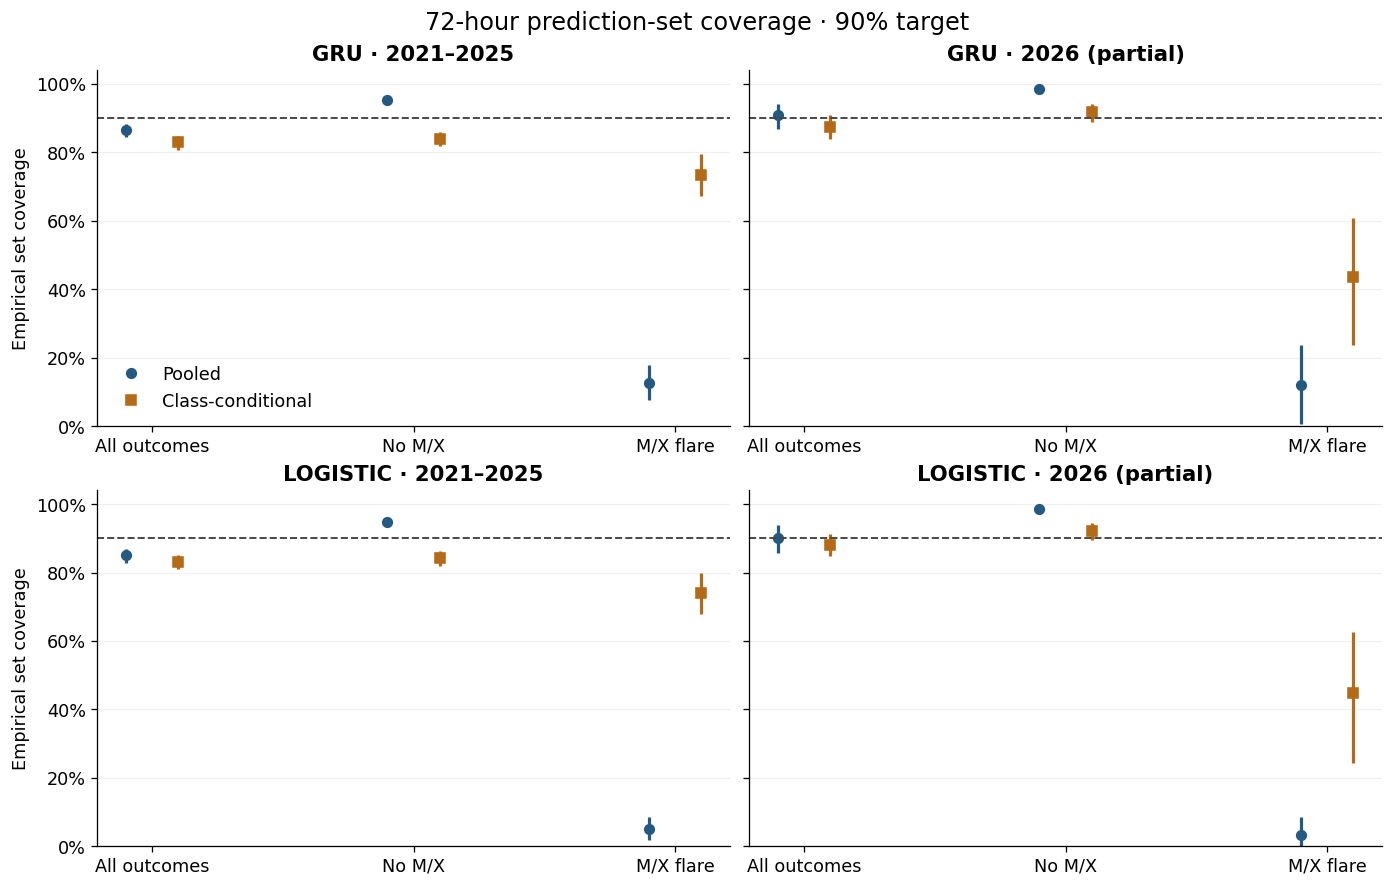

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.6), sharey=True, layout='constrained')
for row, model in enumerate(CONFIG['models']):
    for col, role in enumerate(CONFIG['evaluation_roles']):
        ax = axes[row, col]
        data = intervals[(intervals.model == model) & (intervals.role == role) & intervals.alpha.eq(.1)
                         & intervals.year.eq('all') & intervals.grouping.eq('region_component')]
        for method, offset, marker in [('pooled', -.10, 'o'), ('class_conditional', .10, 's')]:
            values = data[data.method.eq(method)].set_index('population').loc[['all', 'nonflare', 'flare']]
            x = np.arange(3) + offset
            ax.vlines(x, values.low, values.high, color=METHOD_COLORS[method], lw=2)
            ax.plot(x, values.coverage, marker, color=METHOD_COLORS[method], label=METHOD_NAMES[method])
        ax.axhline(.9, color='#444444', ls='--', lw=1.2)
        ax.set(xticks=range(3), xticklabels=['All outcomes', 'No M/X', 'M/X flare'], ylim=(0, 1.04),
               title=f'{model.upper()} · {PERIOD_NAMES[role]}')
        ax.yaxis.set_major_formatter(PercentFormatter(1))
        ax.grid(axis='y', alpha=.18)
        if col == 0: ax.set_ylabel('Empirical set coverage')
axes[0, 0].legend(loc='lower left', frameon=False)
fig.suptitle('72-hour prediction-set coverage · 90% target', fontsize=15)
fig.savefig(OUTPUT_DIR / 'coverage_by_class.png', bbox_inches='tight')
plt.show()

### 10. What the prediction sets contain
Each bar covers the same known-outcome evaluation population used above. Missing-input rows are reported separately below, not absorbed into the empty-set category. These four mathematical set types are not operational safety states.

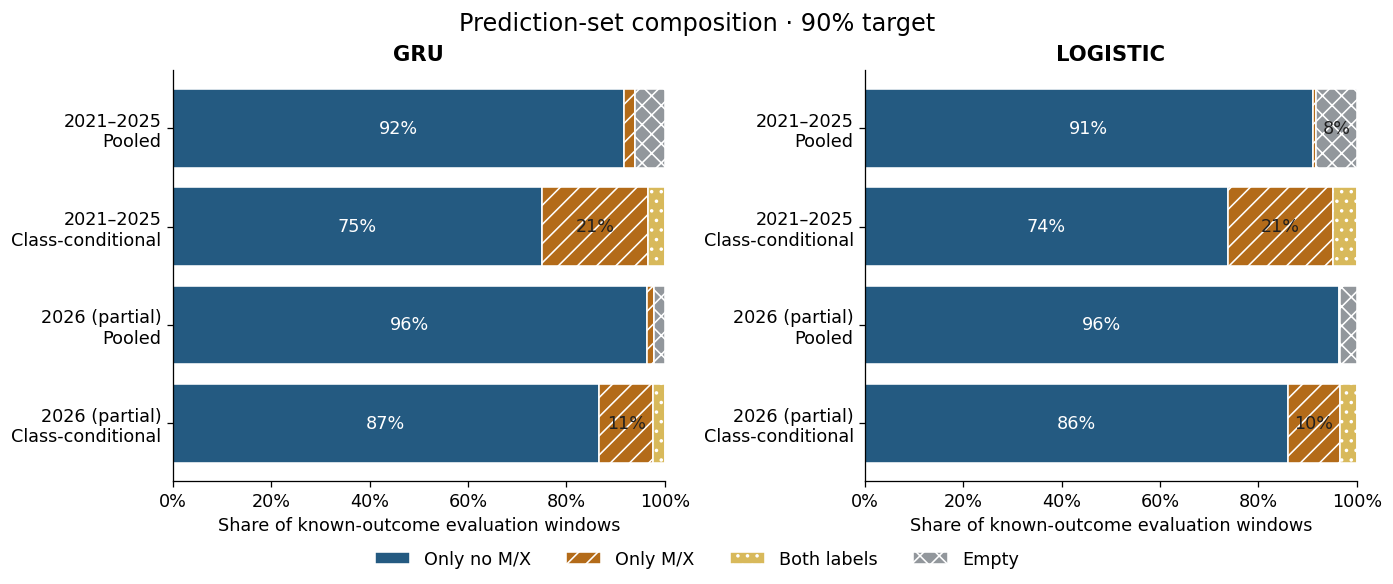

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, layout='constrained')
state_style = [('nonflare_only', 'Only no M/X', '#245A81', ''), ('flare_only', 'Only M/X', '#B36B19', '//'),
               ('both', 'Both labels', '#D8B95B', '..'), ('empty', 'Empty', '#92979C', 'xx')]
for ax, model in zip(axes, CONFIG['models']):
    table = metrics[(metrics.model == model) & metrics.alpha.eq(.1)].copy()
    table['order'] = table.role.map({'retrospective_cycle25': 0, 'supplementary_2026': 2}) + table.method.map({'pooled': 0, 'class_conditional': 1})
    table = table.sort_values('order')
    left = np.zeros(len(table))
    for state, label, color, hatch in state_style:
        values = table[state + '_fraction'].to_numpy()
        ax.barh(np.arange(len(table)), values, left=left, color=color, hatch=hatch, edgecolor='white', label=label)
        for i, width in enumerate(values):
            if width >= .07:
                ax.text(left[i]+width/2, i, f'{width:.0%}', ha='center', va='center', color='white' if state == 'nonflare_only' else '#202020')
        left += values
    ax.set(yticks=np.arange(len(table)), yticklabels=[f'{PERIOD_NAMES[r.role]}\n{METHOD_NAMES[r.method]}' for r in table.itertuples()],
           xlim=(0, 1), title=model.upper(), xlabel='Share of known-outcome evaluation windows')
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(PercentFormatter(1))
fig.legend(*axes[0].get_legend_handles_labels(), loc='outside lower center', ncol=4, frameon=False)
fig.suptitle('Prediction-set composition · 90% target', fontsize=15)
fig.savefig(OUTPUT_DIR / 'set_composition.png', bbox_inches='tight')
plt.show()

### 11. Transfer across years
Annual estimates retain the fixed 2015 thresholds. Bands show conditional region-component bootstrap intervals at the primary 90% target. The final year is partial through the available August 2026 cases; calendar periods differ in duration and event counts.

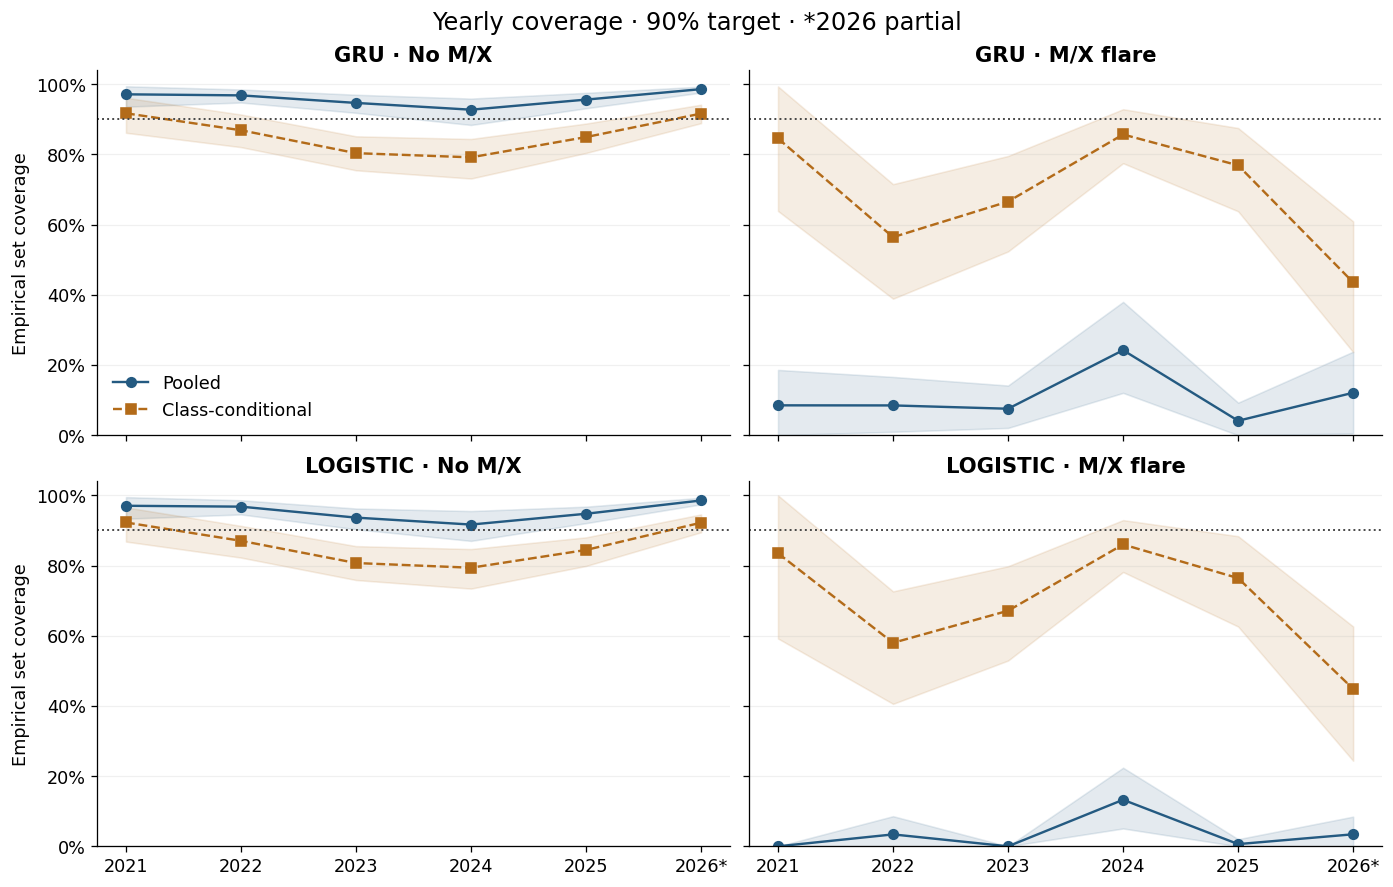

,year,cases,nonflare_cases,flare_cases
0,2021,4351,4163,188
1,2022,7639,6932,707
2,2023,9211,8137,1074
3,2024,7072,5813,1259
4,2025,7573,6941,632
5,2026,11118,10126,992


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.6), sharex=True, sharey=True, layout='constrained')
for row, model in enumerate(CONFIG['models']):
    for col, population_name in enumerate(['nonflare', 'flare']):
        ax = axes[row, col]
        for method, marker, linestyle in [('pooled', 'o', '-'), ('class_conditional', 's', '--')]:
            values = intervals[(intervals.model == model) & intervals.method.eq(method) & intervals.alpha.eq(.1)
                               & intervals.population.eq(population_name) & intervals.year.ne('all')
                               & intervals.grouping.eq('region_component')].copy()
            values['year'] = values.year.astype(int)
            values = values.sort_values('year')
            ax.plot(values.year, values.coverage, marker=marker, ls=linestyle, color=METHOD_COLORS[method], label=METHOD_NAMES[method])
            ax.fill_between(values.year, values.low, values.high, color=METHOD_COLORS[method], alpha=.12)
        ax.axhline(.9, color='#444444', ls=':', lw=1.2)
        ax.set(title=f'{model.upper()} · {"No M/X" if population_name == "nonflare" else "M/X flare"}', ylim=(0, 1.04),
               xticks=range(2021, 2027), xticklabels=['2021', '2022', '2023', '2024', '2025', '2026*'])
        ax.yaxis.set_major_formatter(PercentFormatter(1))
        ax.grid(axis='y', alpha=.18)
        if col == 0: ax.set_ylabel('Empirical set coverage')
axes[0, 0].legend(loc='lower left', frameon=False)
fig.suptitle('Yearly coverage · 90% target · *2026 partial', fontsize=15)
fig.savefig(OUTPUT_DIR / 'yearly_coverage.png', bbox_inches='tight')
plt.show()
support = yearly[(yearly.model == 'gru') & yearly.method.eq('pooled') & yearly.alpha.eq(.1)]
display(support[['year', 'cases', 'nonflare_cases', 'flare_cases']].reset_index(drop=True))

### 12. Dependence sensitivity and population availability
The seven-day resampling provides a sensitivity to the grouping choice; neither scheme establishes independent events. Complete population outputs retain missing inputs and unknown outcomes. The two backbones use matched input cases.

In [13]:
table = intervals[intervals.alpha.eq(.1) & intervals.year.eq('all') & intervals.population.eq('flare')]
display(table[['role', 'model', 'method', 'grouping', 'cases', 'groups_with_class', 'coverage', 'low', 'high']].round(4))
availability = pd.read_csv(OUTPUT_DIR / 'availability.csv')
display(availability[(availability.model == 'gru') & (availability.year >= 2021)].drop(columns='model').reset_index(drop=True))
print('All candidate cases:', summary['population_rows'])
print('All-year missing-input cases:', summary['missing_input_rows'])
print('Mapped region overlap with conformal fit:', summary['calibration_evaluation_region_overlap_counts'])
for name, expected in summary['output_sha256'].items():
    assert sha256(OUTPUT_DIR / name) == expected, name
parent = json.loads((PARENT_DIR / 'summary.json').read_text())
for name, expected in parent['output_sha256'].items():
    assert sha256(PARENT_DIR / name) == expected, name
print('Frozen inputs and saved outputs verified unchanged.')

,role,model,method,grouping,cases,groups_with_class,coverage,low,high
2,retrospective_cycle25,gru,pooled,region_component,3860,137,0.1264,0.0750,0.1791
20,retrospective_cycle25,gru,pooled,calendar_7day_UTC,3860,126,0.1264,0.0781,0.1757
23,supplementary_2026,gru,pooled,region_component,992,22,0.1210,0.0048,0.2381
29,supplementary_2026,gru,pooled,calendar_7day_UTC,992,21,0.1210,0.0142,0.2405
44,retrospective_cycle25,gru,class_conditional,region_component,3860,137,0.7352,0.6737,0.7945
62,retrospective_cycle25,gru,class_conditional,calendar_7day_UTC,3860,126,0.7352,0.6723,0.7911
65,supplementary_2026,gru,class_conditional,region_component,992,22,0.4355,0.2368,0.6093
71,supplementary_2026,gru,class_conditional,calendar_7day_UTC,992,21,0.4355,0.2756,0.5699
86,retrospective_cycle25,logistic,pooled,region_component,3860,137,0.0505,0.0195,0.0845
104,retrospective_cycle25,logistic,pooled,calendar_7day_UTC,3860,126,0.0505,0.0201,0.0846


,year,candidate_cases,missing_inputs,before_conformal_fit_with_inputs,issued_sets,issued_with_unknown_outcome
0,2021,5828,1253,0,4575,224
1,2022,11535,2525,0,9010,1371
2,2023,14676,3489,0,11187,1976
3,2024,14732,3359,0,11373,4301
4,2025,14774,5516,0,9258,1660
5,2026,14923,2764,0,12159,1041


All candidate cases: 153366
All-year missing-input cases: 39933
Mapped region overlap with conformal fit: {'retrospective_cycle25': 0, 'supplementary_2026': 0}
Frozen inputs and saved outputs verified unchanged.


## Takeaways

In [14]:
messages = []
for role in CONFIG['evaluation_roles']:
    for model in CONFIG['models']:
        rows = metrics[(metrics.role == role) & metrics.model.eq(model) & metrics.alpha.eq(.1)].set_index('method')
        pooled, conditional = rows.loc['pooled'], rows.loc['class_conditional']
        messages.append(f"**{model.upper()}, {PERIOD_NAMES[role]}:** pooled overall coverage {pooled.coverage:.1%}, "
                        f"flare coverage {pooled.flare_coverage:.1%}. Class-conditional flare coverage {conditional.flare_coverage:.1%}; "
                        f"both-label sets {conditional.both_fraction:.1%}. Target: 90%.")
display(Markdown('\n\n'.join(messages)))
display(Markdown('### Interpretation limits\n' + '\n'.join('- ' + item for item in summary['limitations'])))

**GRU, 2021–2025:** pooled overall coverage 86.4%, flare coverage 12.6%. Class-conditional flare coverage 73.5%; both-label sets 3.5%. Target: 90%.

**LOGISTIC, 2021–2025:** pooled overall coverage 85.0%, flare coverage 5.1%. Class-conditional flare coverage 73.9%; both-label sets 4.9%. Target: 90%.

**GRU, 2026 (partial):** pooled overall coverage 90.9%, flare coverage 12.1%. Class-conditional flare coverage 43.5%; both-label sets 2.3%. Target: 90%.

**LOGISTIC, 2026 (partial):** pooled overall coverage 90.1%, flare coverage 3.4%. Class-conditional flare coverage 44.9%; both-label sets 3.5%. Target: 90%.

### Interpretation limits
- Candidate event labels, unknown-outcome exclusions and unverified continuous event coverage remain provisional.
- Counts are overlapping forecast windows, not independent flare events. Temporal dependence and cross-cycle drift prevent claiming nominal distribution-free guarantees here.
- Pooled coverage is marginal and can hide low flare-class coverage. Class-conditional coverage also requires within-class exchangeability for its theoretical guarantee.
- Prediction sets describe possible binary outcomes; they are not confidence intervals for flare probabilities, confidence levels for individual cases, or calibrated operational trust states.
- An empty set is not an OOD diagnosis; a singleton is not a safety certificate. Missing inputs stay unscored and unknown outcomes never become negatives.
- Bootstrap intervals are conditional per-comparison group-resampling sensitivities, not simultaneous inference; they omit label, calibration-sample and model-fitting uncertainty.
- Cycle-25 and 2026 data have already been inspected: results are retrospective/supplementary, not prospective independent validation.
- Only the 72-hour SHARP candidate baseline is evaluated. Policy validation, fusion, rolling updates and other horizons remain separate work.

**Next research step:** use the untouched policy-development outcomes to develop a prespecified decision policy, with explicit coverage and error targets, while retaining all failures observed here. Any rolling/adaptive conformal extension must use only outcomes whose forecast windows and declared reporting delay have elapsed. Neither a favorable aggregate coverage number nor this completed notebook establishes operational readiness.

**Reusable outputs:** frozen thresholds, full-population sets, exact numerators/denominators, annual metrics, coverage intervals, availability counts, executable code, and a configuration/runtime/hash receipt in the timestamped output directory. Large per-case files stay local; compact receipts and this executed notebook are versioned in the repository.